# Manual MOSFET Calculations Using the Level 1 Model

This notebook estimates the operating point and small-signal parameters of an NMOS transistor, and calculates its intrinsic, overlap, and diffusion capacitances. The equations are included to connect the theory to the Python implementation. Device dimensions are in meters, voltages in volts, currents in amperes, and capacitances in farads.

The first code cell imports NumPy for mathematical operations and the libraries used to display results in engineering notation.

In [32]:
"""Hand calculations for a MOSFET using the Level 1 model."""

import numpy as np

from si_prefix import si_format as num2eng
from prettytable import PrettyTable
import matplotlib.pyplot as plt

## Device Geometry and Bias

This section defines the channel width and length, along with the supply and bias voltages. The source is the reference for $V_{GS}$ and the body for $V_{SB}$. The code sets the gate-source and drain-source voltages to half the supply voltage:

$$V_{GS}=V_{DS}=\frac{V_{DD}}{2}, \qquad V_{SB}=0.$$

These values determine the operating point evaluated in the following sections.

In [ ]:
# First we define the parameters of the MOSFET. These are taken from Razavi book for 180nm technology.
# Device geometry (m)
W = 1e-6
L = 0.18e-6

# Bias voltages (V)
VDD = 1.8
VSB = 0
VGS = VDD / 2
VDS = VDD / 2

## Level 1 Model Parameters

The NMOS and process parameters are assigned here: surface potential $\phi$, body-effect coefficient $\gamma$, channel-length modulation coefficient $\lambda$, nominal threshold voltage $V_{TH}$, and transconductance parameter $k_p$. The oxide thickness, overlap and junction capacitance parameters, and diffusion length $L_D$ are also specified.

Units are noted in the code comments to distinguish, for example, capacitance per unit area (F/m$^2$) from capacitance per unit length (F/m).

In [ ]:
# Level 1 NMOS model parameters
phi = 0.3       # Surface-potential parameter (V)
gamma = 0.4     # Body-effect coefficient (V**0.5)
lmbda = 0.1     # Channel-length modulation coefficient (1/V)
VTH0 = 0.4       # Zero-bias threshold voltage (V)
kp = 100e-6     # Process transconductance parameter (A/V**2)

# Oxide, gate-overlap, and source/drain junction capacitance parameters
tox = 40e-10    # Gate-oxide thickness (m)
CGSO = 9.55e-10 # Gate-source overlap capacitance per unit width (F/m)
CGDO = 9.55e-10 # Gate-drain overlap capacitance per unit width (F/m)
CGBO = 0        # Gate-bulk overlap capacitance per unit length (F/m)
Cj = 9.81e-4    # Bottom-junction capacitance per unit area (F/m**2)
Cjsw = 1.19e-10 # Sidewall-junction capacitance per unit length (F/m)
LD = 0.48e-6    # Source/drain diffusion length (m)
mjsw = 0        # Sidewall-junction grading coefficient
mj = 0          # Bottom-junction grading coefficient


## Operating Point and Small-Signal Parameters

First, the threshold voltage is calculated using the body-effect expression implemented in the code, followed by the saturation voltage:

$$V_{TH}=V_{TH0}+\gamma\left(\sqrt{|V_{SB}-\phi|}-\sqrt{\phi}\right), \qquad V_{DSAT}=V_{GS}-V_{TH1}.$$

For the Level 1 model, the code evaluates the drain current including channel-length modulation and derives the small-signal conductances:

$$I_D=\frac{1}{2}k_p\frac{W}{L}(V_{GS}-V_{TH})^2(1+\lambda V_{DS}),$$
$$g_m=k_p\frac{W}{L}(V_{GS}-V_{TH})(1+\lambda V_{DS}), \qquad
g_{mb}=g_m\frac{\gamma}{2\sqrt{|V_{SB}-\phi|}}, \qquad
g_{ds}=\lambda I_D.$$

The operating region is then identified using the conditions in the code, and the bias point, current, and conductances are printed.

In [ ]:
# Large-signal operating point: body-effect threshold and saturation voltage

VTH = VTH0 + gamma * (np.sqrt(abs(-phi + VSB)) - np.sqrt(phi))
VDSat = VGS - VTH

# Level 1 drain-current and small-signal equations (including channel-length modulation)
ID = 0.5 * kp * (W / L) * (VGS - VTH)**2 * (1 + lmbda * VDS)
gm = kp * (W / L) * (VGS - VTH) * (1 + lmbda * VDS)
gmb = gm * gamma / (2 * np.sqrt(abs(-phi + VSB)))
gds = ID * lmbda

# Classify the operating region for the biased device.
if VDS >= VDSat:
    region = "Saturation"
elif VDS <= 20e-3:
    region = "Triode"
else:
    region = "Cut-off"

# Report the bias point, current, and small-signal conductances.
myTable = PrettyTable(["Parameter", "Value"])
myTable.add_row(["Region", region])
myTable.add_row(["ID", num2eng(float(ID)) + "A"])
myTable.add_row(["VGS", num2eng(float(VGS)) + "V"])
myTable.add_row(["VDS", num2eng(float(VDS)) + "V"])
myTable.add_row(["VSB", num2eng(float(VSB)) + "V"])
myTable.add_row(["VTH", num2eng(float(VTH)) + "V"])
myTable.add_row(["VDSat", num2eng(float(VDSat)) + "V"])
myTable.add_row(["gm", num2eng(float(gm)) + "S"])
myTable.add_row(["gds", num2eng(float(gds)) + "S"])
myTable.add_row(["gmb", num2eng(float(gmb)) + "S"])
print(myTable)


+-----------+------------+
| Parameter |   Value    |
+-----------+------------+
|   Region  | Saturation |
|     ID    |  75.7 µA   |
|    VGS    |  900.0 mV  |
|    VDS    |  900.0 mV  |
|    VSB    |   0.0 V    |
|    VTH    |  400.0 mV  |
|   VDSat   |  500.0 mV  |
|     gm    |  302.8 µS  |
|    gds    |   7.6 µS   |
|    gmb    |  110.6 µS  |
+-----------+------------+


## MOSFET Capacitances

The gate-oxide capacitance per unit area is calculated as:

$$C_{ox}=\frac{\epsilon_{ox}}{t_{ox}}, \qquad \epsilon_{ox}=3.9\epsilon_0.$$

### Intrinsic Gate Capacitances

The code uses the following region-dependent approximations, with $C_{ox}WL$ as the total channel capacitance:

| Región | $C_{GB}$ | $C_{GS}$ | $C_{GD}$ |
|---|---:|---:|---:|
| Corte | $C_{ox}WL$ | $0$ | $0$ |
| Triodo | $0$ | $C_{ox}WL/2$ | $C_{ox}WL/2$ |
| Saturación | $0$ | $2C_{ox}WL/3$ | $0$ |

### Overlap, Diffusion, and Total Capacitances

Overlap capacitances are obtained by multiplying the per-unit-length parameters by the device width:

$$C_{GB,ov}=C_{GBO}W, \qquad C_{GS,ov}=C_{GSO}W, \qquad C_{GD,ov}=C_{GDO}W.$$

The diffusion area and perimeter are $A_S=WL_D$ and $P_S=2W+2L_D$. Junction capacitances are estimated by adding the bottom-area and sidewall contributions:

$$C_{SB}=C_jA_S+C_{jsw}P_S, \qquad C_{DB}=C_jA_S+C_{jsw}P_S.$$

Finally, the reported total gate capacitances are calculated by adding the corresponding intrinsic and overlap capacitances:

$$C_{GS,total}=C_{GS}+C_{GS,ov}, \qquad C_{GD,total}=C_{GD}+C_{GD,ov}, \qquad C_{GB,total}=C_{GB}+C_{GB,ov}.$$

The following code cell prints each contribution and the totals for all three operating regions.

In [31]:
# Capacitance calculations
# Gate-oxide capacitance per unit area (F/m**2)
eo = 8.8854e-12
eox = 3.9 * eo
Cox = eox / tox

# Intrinsic gate-channel capacitances by operating region (Level 1 model).
# Cutoff: gate couples to the body; triode: channel charge is split equally;
# saturation: the channel charge is assigned two-thirds to the source.
CGB_off = Cox * W * L
CGB_triode = 0
CGB_sat = 0

CGS_off = 0
CGS_triode = Cox * W * L / 2
CGS_sat = (2 / 3) * Cox * W * L

CGD_off = 0
CGD_triode = Cox * W * L / 2
CGD_sat = 0

print("\nIntrinsic Channel Capacitances")
myTable = PrettyTable(["Region", "CGB [F]", "CGS [F]", "CGD [F]"])
myTable.add_row(["Cutoff", num2eng(float(CGB_off), 2), num2eng(float(CGS_off), 2), num2eng(float(CGD_off), 2)])
myTable.add_row(["Triode", num2eng(float(CGB_triode), 2), num2eng(float(CGS_triode), 2), num2eng(float(CGD_triode), 2)])
myTable.add_row(["Saturation", num2eng(float(CGB_sat), 2), num2eng(float(CGS_sat), 2), num2eng(float(CGD_sat), 2)])
print(myTable)


# Gate overlap capacitances from per-unit-length model parameters.
CGB_ov = CGBO * W
CGS_ov = CGSO * W
CGD_ov = CGDO * W

print("\nOverlap Capacitances")
myTable = PrettyTable(["Overlap", "CGB_ov [F]", "CGS_ov [F]", "CGD_ov [F]"])
myTable.add_row(["Value", num2eng(float(CGB_ov), 2), num2eng(float(CGS_ov), 2), num2eng(float(CGD_ov), 2)])

print(myTable)


# Source/drain diffusion area and perimeter used in junction-capacitance estimates.
PS = 2 * W + 2 * LD
AS = W * LD

print("\nDiffusion Areas and Perimeters")
print("Area =", num2eng(float(AS), 2), "m^2")
print("Perimeter =", num2eng(float(PS), 2), "m")

# Junction capacitance = bottom-area contribution + sidewall contribution.
CSB = Cj * AS + Cjsw * PS
CDB = Cj * AS + Cjsw * PS

print("\nDiffusion Capacitances")
myTable = PrettyTable(["Parameter", "CSB_diff [F]", "CDB_diff [F]"])
myTable.add_row(["Value", num2eng(float(CSB), 2), num2eng(float(CDB), 2)])
print(myTable)

# Combine intrinsic, overlap, and diffusion contributions for the totals.
print("\nTotal Capacitances")
CGS_off_total = CGS_off + CGS_ov
CGS_triode_total = CGS_triode + CGS_ov
CGS_sat_total = CGS_sat + CGS_ov

CGD_off_total = CGD_off + CGD_ov
CGD_triode_total = CGD_triode + CGD_ov
CGD_sat_total = CGD_sat + CGD_ov

CGB_off_total = CGB_off + CGB_ov
CGB_triode_total = CGB_triode + CGB_ov
CGB_sat_total = CGB_sat + CGB_ov

myTable = PrettyTable(["Region", "CGB_total [F]", "CGS_total [F]", "CGD_total [F]"])
myTable.add_row(["Cutoff", num2eng(float(CGB_off_total), 2), num2eng(float(CGS_off_total), 2), num2eng(float(CGD_off_total), 2)])
myTable.add_row(["Triode", num2eng(float(CGB_triode_total), 2), num2eng(float(CGS_triode_total), 2), num2eng(float(CGD_triode_total), 2)])
myTable.add_row(["Saturation", num2eng(float(CGB_sat_total), 2), num2eng(float(CGS_sat_total), 2), num2eng(float(CGD_sat_total), 2)])
print(myTable)




Intrinsic Channel Capacitances
+------------+---------+----------+----------+
|   Region   | CGB [F] | CGS [F]  | CGD [F]  |
+------------+---------+----------+----------+
|   Cutoff   |  1.56 f |  0.00    |  0.00    |
|   Triode   |  0.00   | 779.69 a | 779.69 a |
| Saturation |  0.00   |  1.04 f  |  0.00    |
+------------+---------+----------+----------+

Overlap Capacitances
+---------+------------+------------+------------+
| Overlap | CGB_ov [F] | CGS_ov [F] | CGD_ov [F] |
+---------+------------+------------+------------+
|  Value  |   0.00     |  955.00 a  |  955.00 a  |
+---------+------------+------------+------------+

Diffusion Areas and Perimeters
Area = 480.00 f m^2
Perimeter = 2.96 µ m

Diffusion Capacitances
+-----------+--------------+--------------+
| Parameter | CSB_diff [F] | CDB_diff [F] |
+-----------+--------------+--------------+
|   Value   |   823.12 a   |   823.12 a   |
+-----------+--------------+--------------+

Total Capacitances
+------------+-----------

## Comparing hand calculations with LTspice

Output generated from DC_Sweep_Razavi

```text
Name:         u1:M1       u2:M1
Model:         nch         pch
Id:          7.57e-05   -3.78e-05
Vgs:         9.00e-01   -9.00e-01
Vds:         9.00e-01   -9.00e-01
Vbs:         0.00e+00    0.00e+00
Vth:         4.00e-01   -4.00e-01
Vdsat:       5.00e-01   -5.00e-01
Gm:          3.03e-04    1.51e-04
Gds:         6.94e-06    3.47e-06
Gmb:         1.11e-04    5.53e-05
Cbd:         8.23e-16    8.23e-16
Cbs:         8.23e-16    8.23e-16
Cgsov:       9.55e-16    9.55e-16
Cgdov:       9.55e-16    9.55e-16
Cgbov:       0.00e+00    0.00e+00
Cgs:         1.04e-15    1.04e-15
Cgd:         0.00e+00    0.00e+00
Cgb:         0.00e+00    0.00e+00
```

In LTspice intrinsic capacitances are shown as: Cgs, Cgd and Cgb
You may need to calculate the complete Cgs, Cgd and Cgb capacitances by hand, in general, the results are similar.

## Plotting the Drain Current in Python

The following code uses NumPy to create arrays of $V_{DS}$ or $V_{GS}$ values with `np.arange`. For each sweep, it evaluates the Level 1 drain-current expressions for the triode and saturation regions, keeping the other bias voltages fixed:

$$I_{D,triode}=\frac{1}{2}k_p\frac{W}{L}\left[2(V_{GS}-V_{TH})V_{DS}-V_{DS}^2\right](1+\lambda V_{DS}),$$
$$I_{D,sat}=\frac{1}{2}k_p\frac{W}{L}(V_{GS}-V_{TH})^2(1+\lambda V_{DS}).$$

`matplotlib.pyplot` draws both current curves with `plt.plot`. The current arrays are multiplied by $10^6$ to display microamperes. `plt.vlines` adds a dashed reference at $V_{DSAT}$ for the $V_{DS}$ sweep and at $V_{TH}$ for the $V_{GS}$ sweep. The title, axis labels, tick sizes, limits, grid, and legend make the plots easier to interpret; `plt.show()` displays each figure.

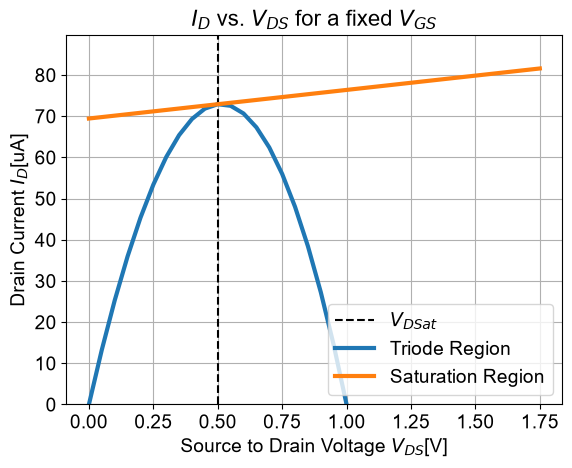

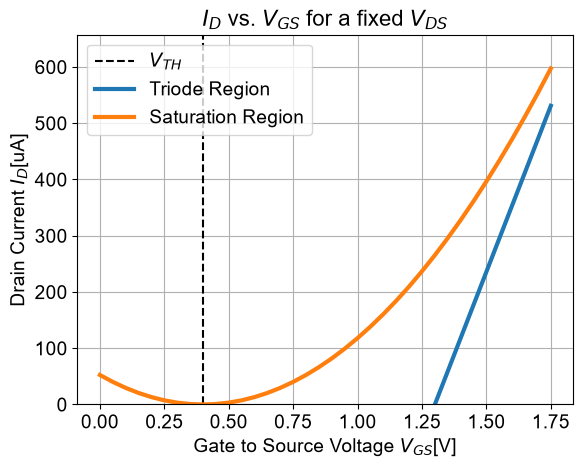

In [ ]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] 


# VDS sweep for a fixed VGS and VSB. The drain current is calculated for both the triode and saturation regions.
VDS = np.arange(0, 1.8, 0.05) # Sweep VDS from 0 to 1.8V in steps of 0.05V
VGS = VDD / 2
VSB = 0
ID_triode = 0.5*kp*(W/L)*(2*(VGS-VTH)*VDS-(VDS**2))*(1+lmbda*VDS)
ID_saturation = 0.5*kp*(W/L)*((VGS-VTH)**2)*(1+lmbda*VDS)

plt.vlines(VDSat, 0, max(ID_saturation*1e6)*1.1, colors='k', linestyles='dashed', label = r'$V_{DSat}$')
plt.plot(VDS, ID_triode*1e6, linewidth = 3, label = 'Triode Region')
plt.plot(VDS, ID_saturation*1e6, linewidth = 3, label = 'Saturation Region')
plt.title(r'$I_D$ vs. $V_{DS}$ for a fixed $V_{GS}$', weight='normal',fontsize=16)
plt.xlabel(r'Source to Drain Voltage $V_{DS}$[V]',weight='normal',fontsize=14)
plt.ylabel(r'Drain Current $I_D$[uA]', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0,max(ID_saturation*1e6)*1.1)
plt.grid()
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="lower right")
plt.show()


# VGS sweep for a fixed VDS and VSB. The drain current is calculated for both the triode and saturation regions.
VGS = np.arange(0, 1.8, 0.05) # Sweep VGS from 0 to 1.8V in steps of 0.05V
VDS = VDD
VSB = 0
ID_triode = 0.5*kp*(W/L)*(2*(VGS-VTH)*VDS-(VDS**2))*(1+lmbda*VDS)
ID_saturation = 0.5*kp*(W/L)*((VGS-VTH)**2)*(1+lmbda*VDS)

plt.vlines(VTH, 0, max(ID_saturation*1e6)*1.1, colors='k', linestyles='dashed', label = r'$V_{TH}$')
plt.plot(VGS, ID_triode*1e6, linewidth = 3, label = 'Triode Region')
plt.plot(VGS, ID_saturation*1e6, linewidth = 3, label = 'Saturation Region')
plt.title(r'$I_D$ vs. $V_{GS}$ for a fixed $V_{DS}$', weight='normal',fontsize=16)
plt.xlabel(r'Gate to Source Voltage $V_{GS}$[V]',weight='normal',fontsize=14)
plt.ylabel(r'Drain Current $I_D$[uA]', weight='normal',fontsize=14)
plt.xticks(weight='normal',fontsize=14)
plt.yticks(weight='normal',fontsize=14)
plt.ylim(0,max(ID_saturation*1e6)*1.1)
plt.grid()
plt.legend(prop = { "size": 14 ,'weight':'normal'}, loc ="upper left")
plt.show()